# Dwarf T<sub>eff</sub> and (B-V) Color

Uses Eric Mamajek's "A Modern Mean Dwarf Stellar Color and Effective Temperature Sequence"
 * http://www.pas.rochester.edu/~emamajek/EEM_dwarf_UBVIJHK_colors_Teff.txt

Version 2022.04.16

Slight modification of the input file to make everything not the data header or data table a comment 
including the extensive notes at the end of the file.

Plots T<sub>eff</sub> vs (B-V) color for dwarf stars.


In [29]:
%matplotlib inline

import os, sys, math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Standard Plot Format

Setup the standard plotting format and make the plot.  

#### Figure Filename

`figName` sets the figure filename of the form `Fig<chapterNum>_<figNum>`, the figure number may also 
include a lowercase  letter for a subfigure (e.g., Fig1_2a).  

#### Aspect Ratio

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

In [30]:
aspWidth = 16
aspHeight = 9

figName = f'Dwarf_Teff_Color' 

aspect = aspWidth/aspHeight

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 8
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)

# Plot filename

plotFile = f'{figName}.{figFmt}'

# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

## Mamajek's stellar color/Teff table

Modified to add comments for all notes.  Read using pandas.  We tell pandas to treat `...` as `NaN` for 
missing data..


In [31]:
dwFile = 'EEM_dwarf_UBVIJHK_colors_Teff.txt'

dwData = pd.read_csv(dwFile,sep=r'\s+',comment='#',na_values='...')

Teff = np.array(dwData['Teff'])
bvColor = np.array(dwData['B-V'])

# Data for the Sun following Pecaut & Mamajek 2013

MVSun = 4.74
teSun = 5772. # K
bvSun = 0.653

# Some reference spectral types

spTypes = ['O3v','B0v','B5v','A0v','F0v','G0v','K0v','M0v','M5v','M9v']
spTemps = [44900,31400,15700,9700 ,7220 ,5930 ,5270 ,3850 ,3060 ,2380]


### Ballesteros 2012, EPL, 97, 2012 B-V to Teff conversion

In [32]:
def bv2Teff(bv):
    Teff = 4600.0*((1.0/(0.92*bv+1.7))+(1.0/(0.92*bv+0.62)))
    return Teff


### Plot it

Plot T<sub>eff</sub> vs B-V color for dwarf stars, put a larger red dot for the Sun.


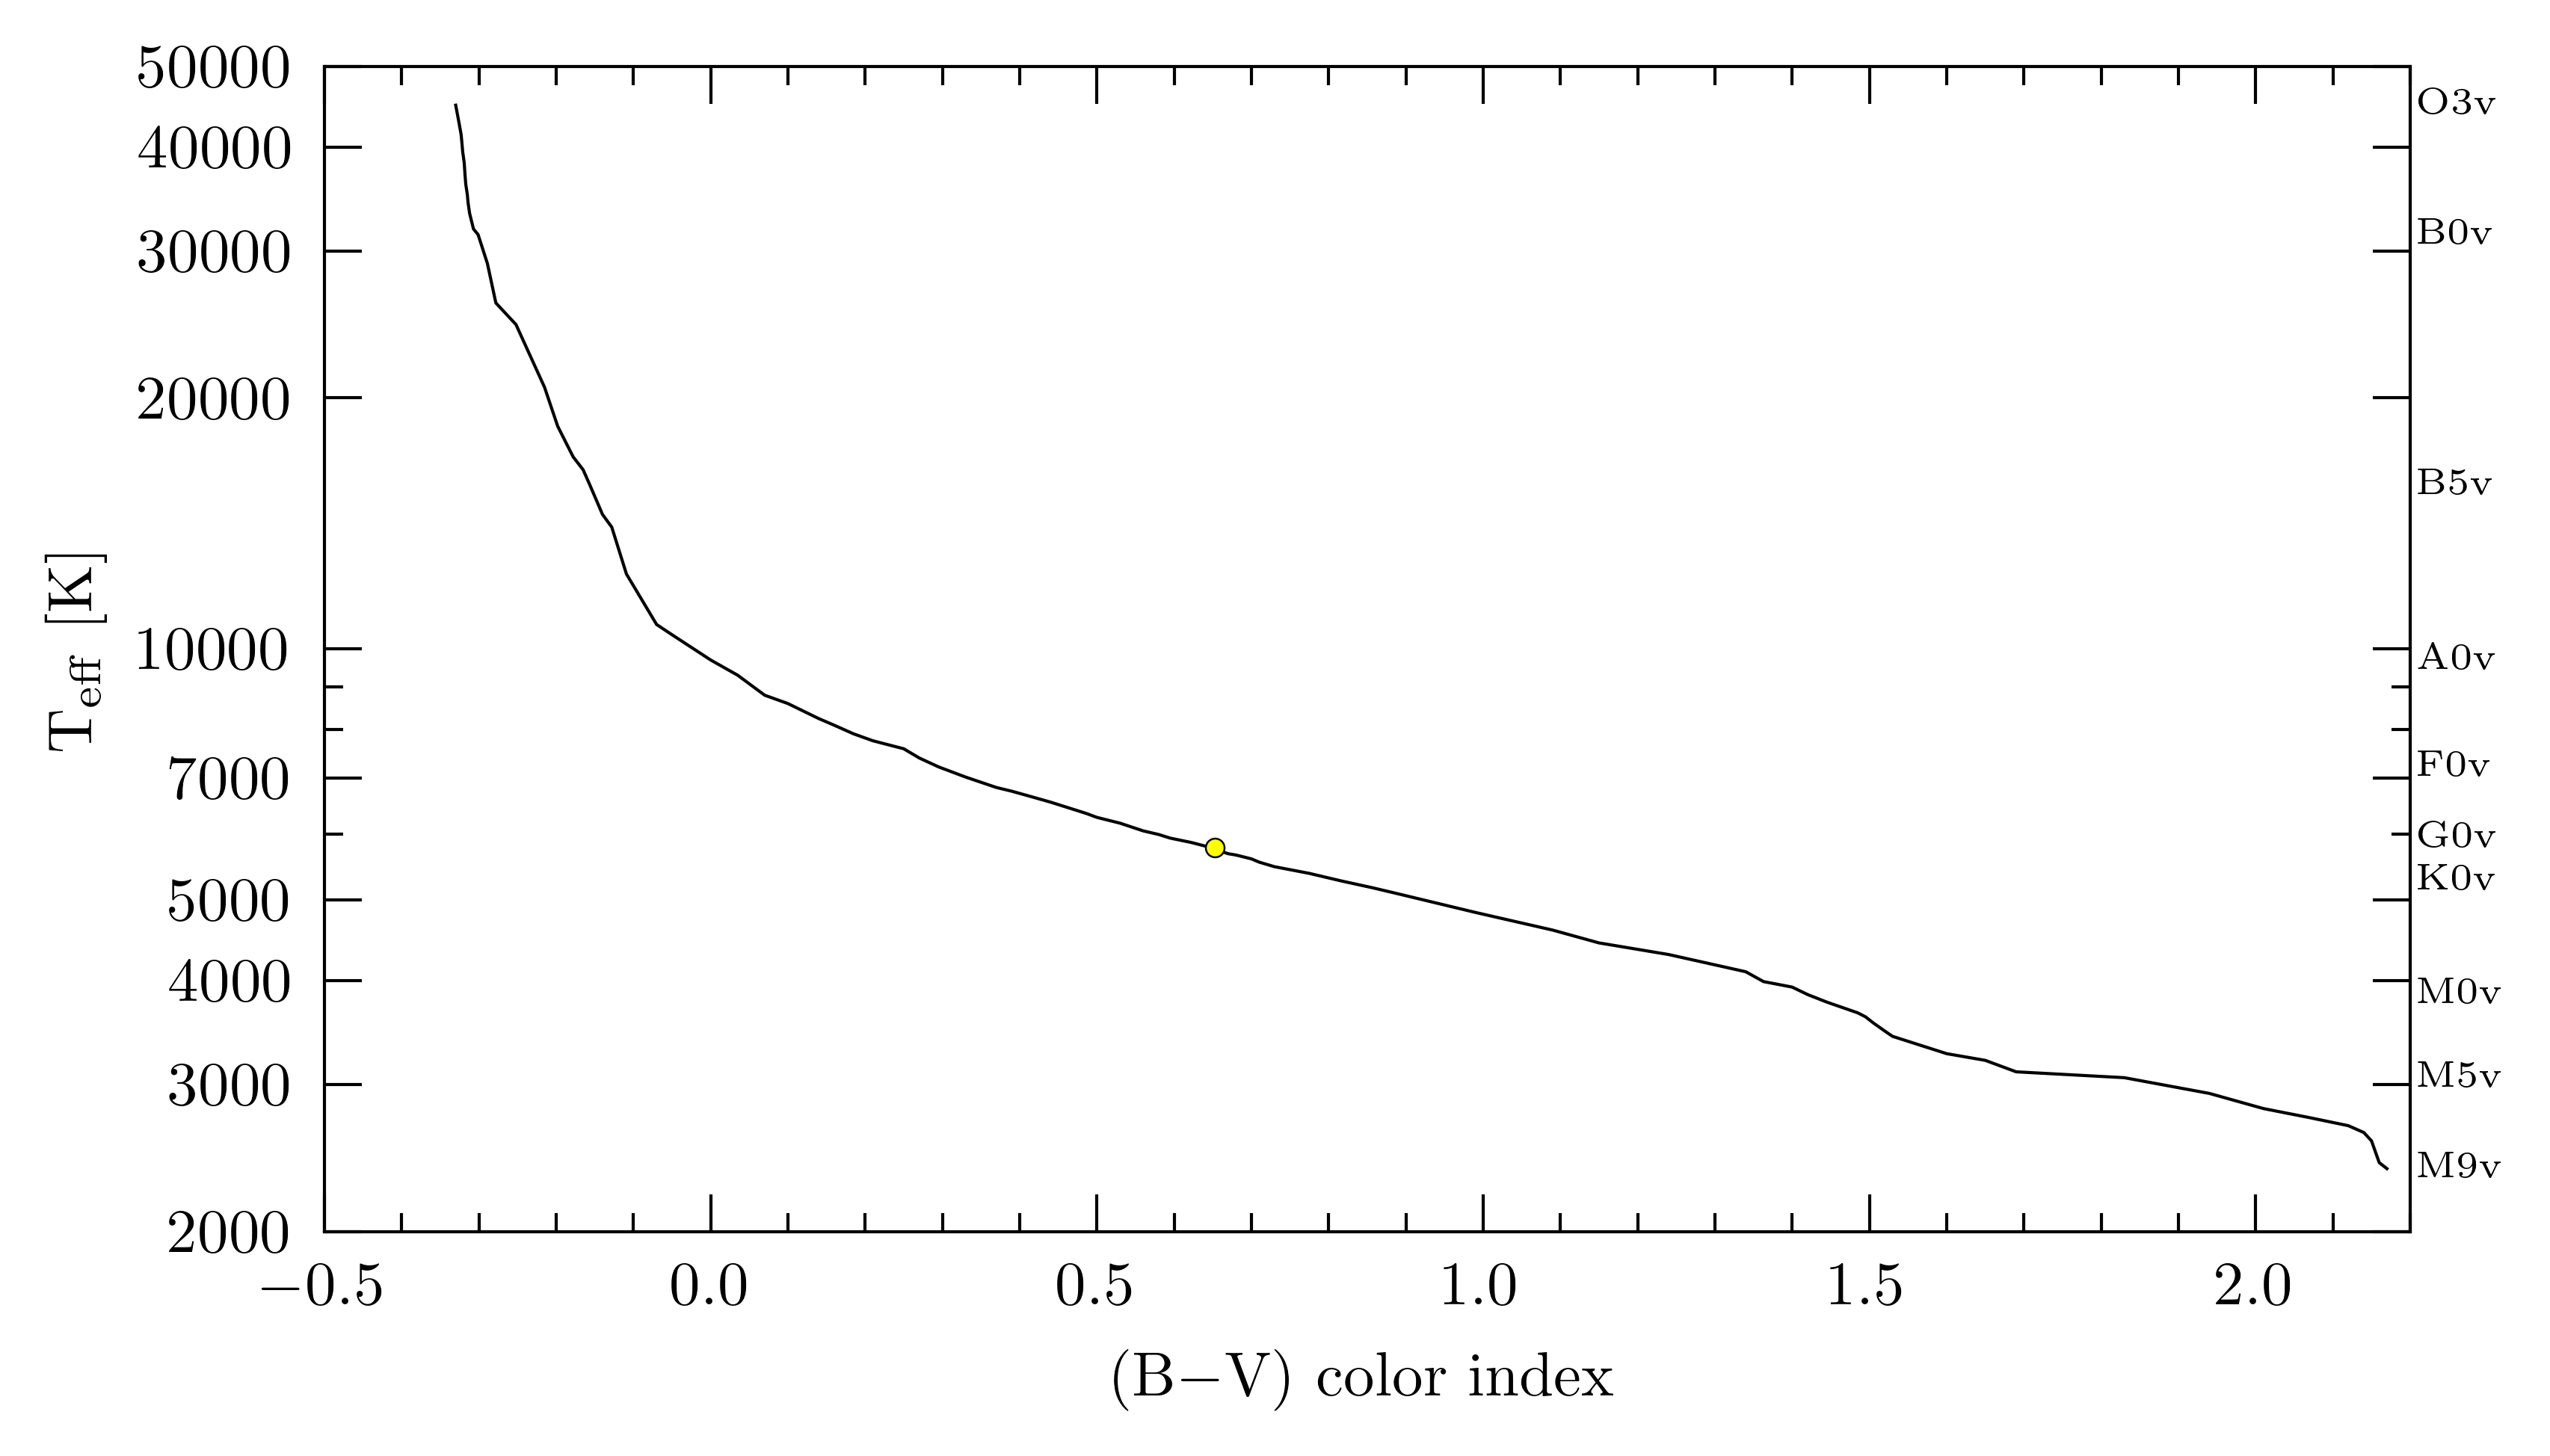

In [33]:
# make the plot

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)
    
ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

bvMin = -0.5
bvMax = 2.2

teMin = 2000 # K
teMax = 50000

ax.set_xlim(bvMin,bvMax)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_xlabel(r'(B$-$V) color index',fontsize=axisFontSize)

ax.set_ylim(teMin,teMax)
ax.set_yscale('log')
ax.set_yticks([2000,3000,4000,5000,7000,10000,20000,30000,40000,50000])
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(numticks=99, subs="auto"))
ax.set_ylabel(r'T$_{\rm eff}$ [K]',fontsize=axisFontSize)
              
ax.plot(bvColor,Teff,'-',color='black',lw=0.5,zorder=9)

# boss! boss! the Sun! the Sun!

ax.plot(bvSun,teSun,'o',ms=3,mfc='yellow',mec='black',mew=0.3,zorder=10)

# label some spectral types at right

for i in range(len(spTypes)):
    ax.text(bvMax+0.01,spTemps[i],spTypes[i],va='center',ha='left',fontsize=6)
    
plt.savefig(plotFile,bbox_inches='tight',facecolor='white')
plt.show()

## Empirical Teff-color relation

An empirical Teff-color relation often used in textbooks is

$$T_{eff}\approx\frac{9000 K}{(B-V)+0.93}$$

How good is it?  Some comparison plots

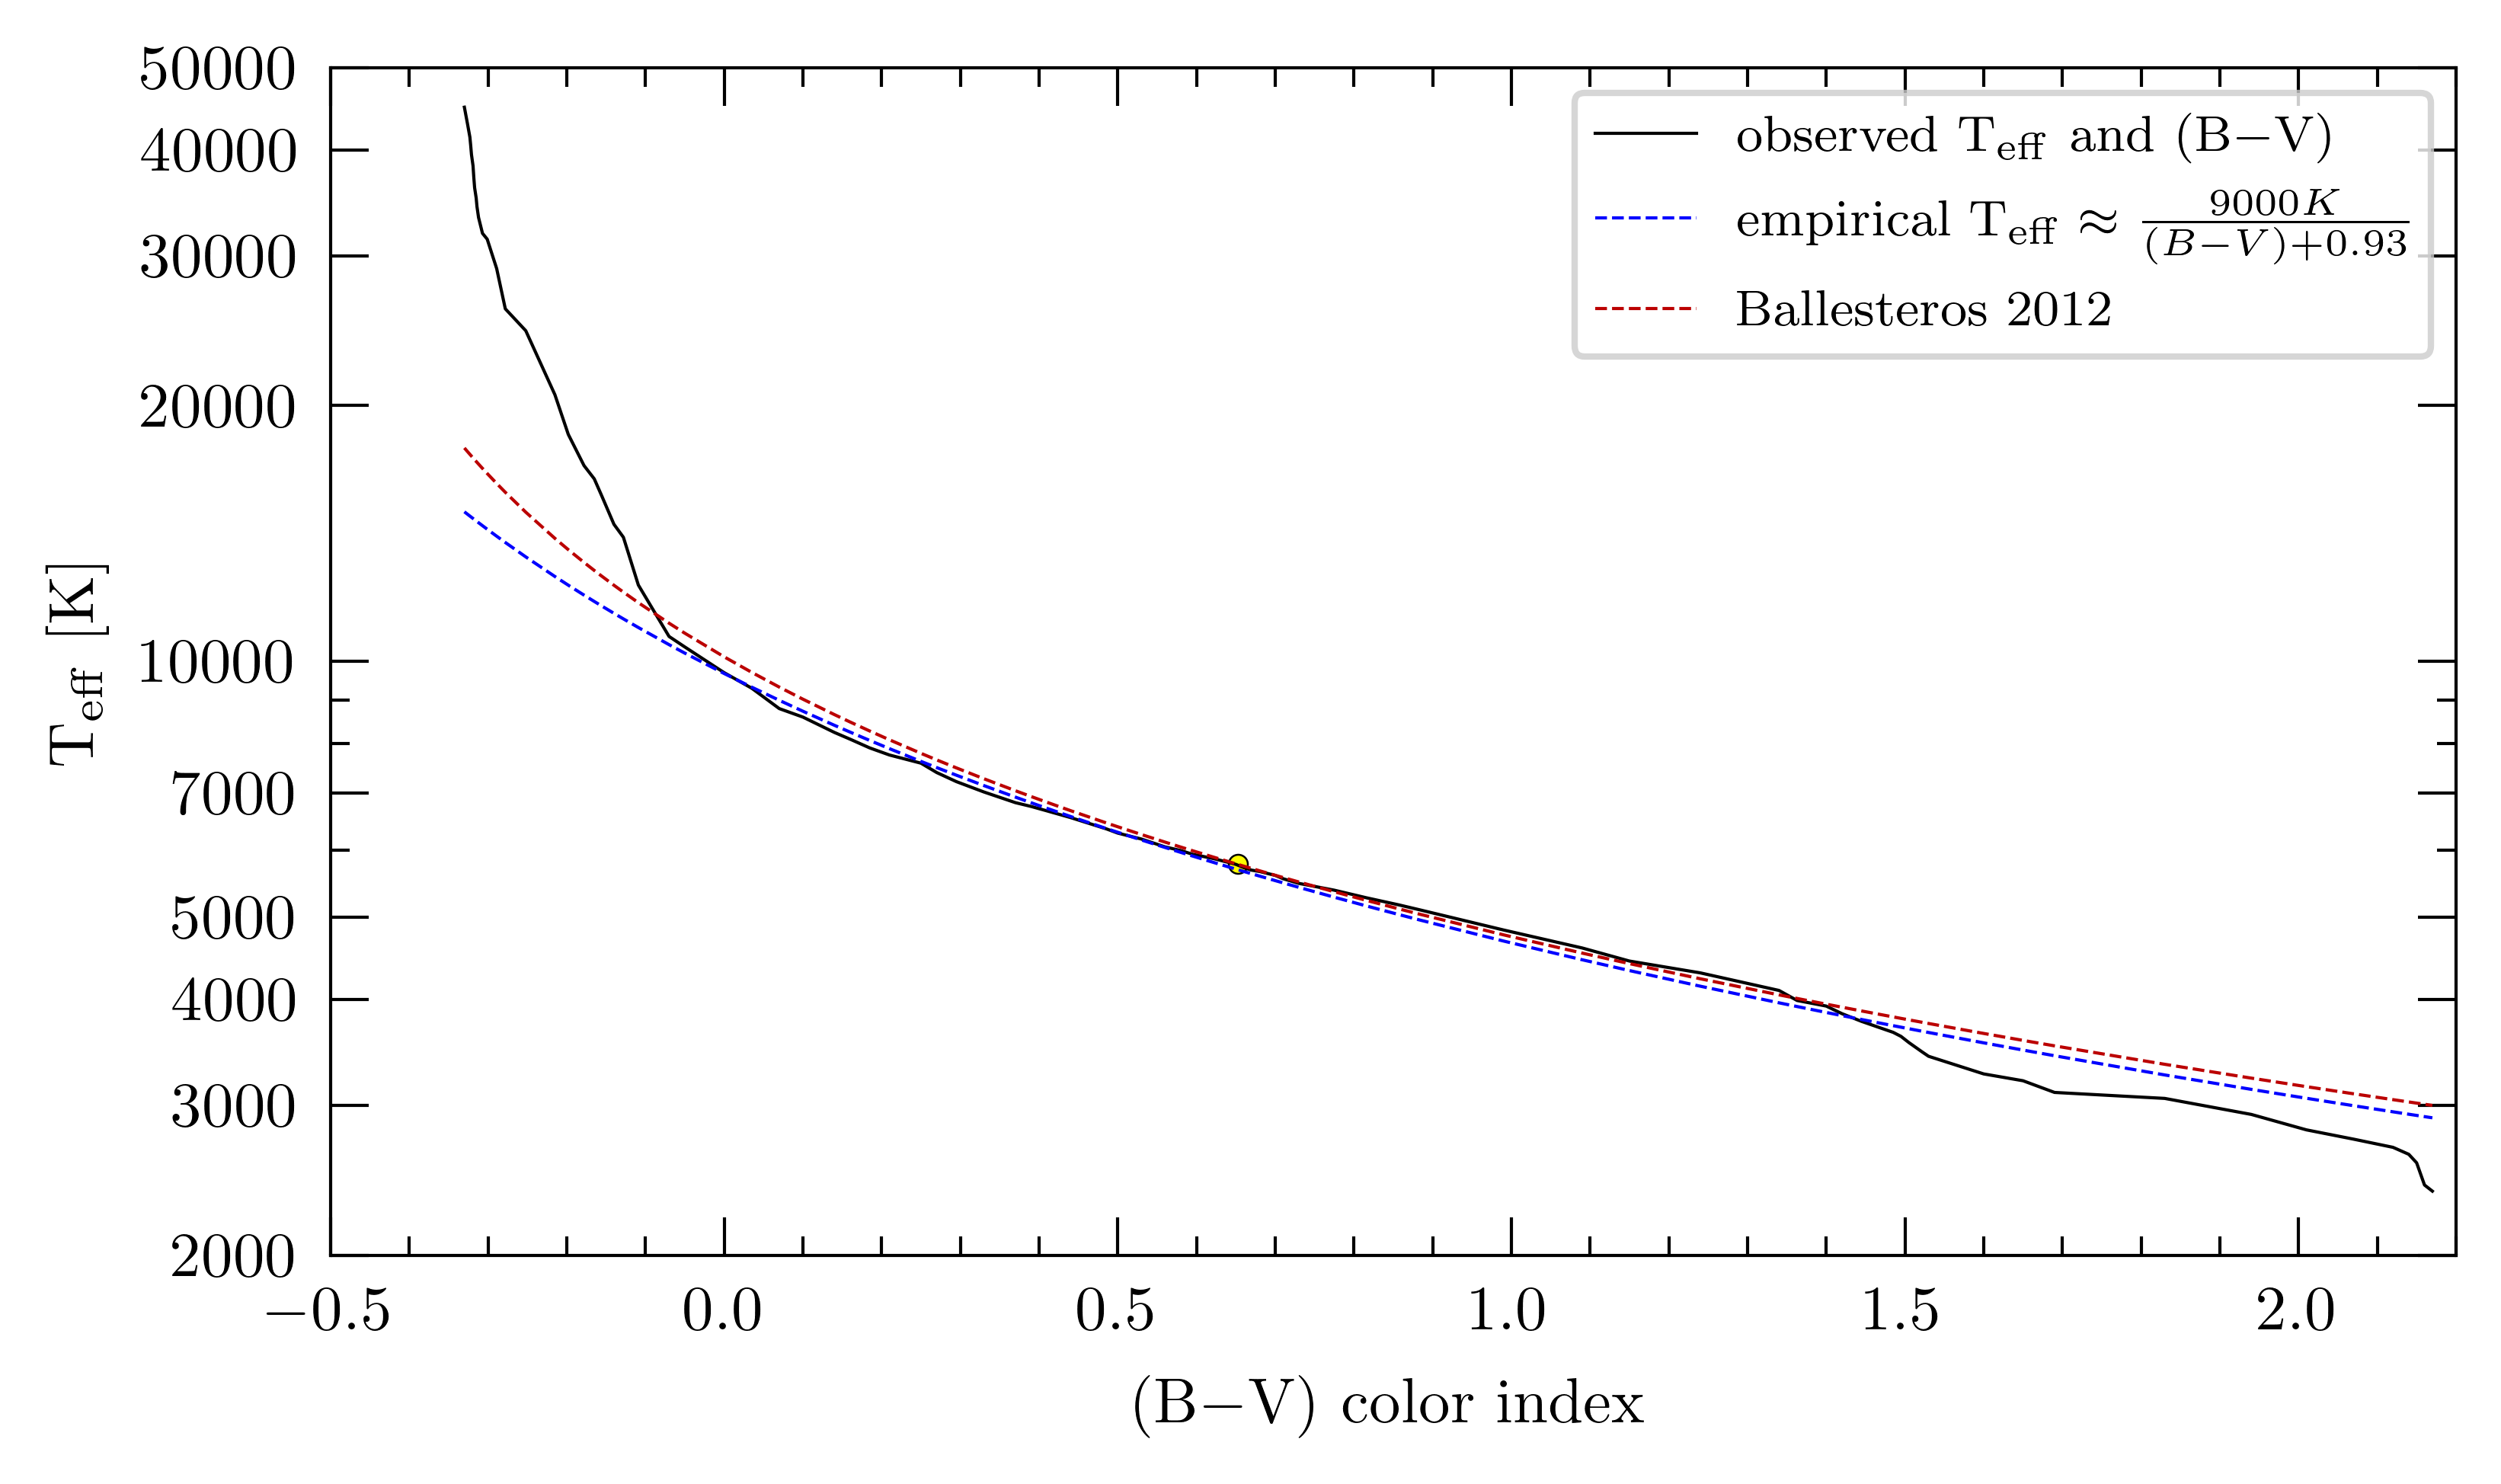

In [34]:
# empirical Teff from Foundations

empTeff = 9000.0/(bvColor+0.93)

# empirical Teff from Ballesteros 2012

b12Teff = 4600.0*((1.0/(0.92*bvColor+1.7))+(1.0/(0.92*bvColor+0.62)))

# make the plot

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)
    
ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

bvMin = -0.5
bvMax = 2.2

teMin = 2000 # K
teMax = 50000

ax.set_xlim(bvMin,bvMax)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_xlabel(r'(B$-$V) color index',fontsize=axisFontSize)

ax.set_ylim(teMin,teMax)
ax.set_yscale('log')
ax.set_yticks([2000,3000,4000,5000,7000,10000,20000,30000,40000,50000])
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(numticks=99, subs="auto"))
ax.set_ylabel(r'T$_{\rm eff}$ [K]',fontsize=axisFontSize)
              
ax.plot(bvColor,Teff,'-',color='black',lw=0.5,zorder=9,label=r'observed T$_{\rm eff}$ and (B$-$V)')

# boss! boss! the Sun! the Sun!

ax.plot(bvSun,teSun,'o',ms=3,mfc='yellow',mec='black',mew=0.3,zorder=8)

# empirical relation as a -- line

ax.plot(bvColor,empTeff,'--',color='blue',lw=0.5,zorder=10,label=r'empirical T$_{\rm eff}\approx\frac{9000K}{(B-V)+0.93}$')
ax.plot(bvColor,b12Teff,'--',color='#bb0000',lw=0.5,zorder=10,label=r'Ballesteros 2012')

ax.legend(fontsize=labelFontSize)

plotFile = f'Dwarf_Teff_Color_Empirical.png' 
plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

plt.show()

## Comparison

Computes the fractional difference in effective temperature between the actual and empirical values derived from the 
B-V color index:
\begin{equation}
  \frac{\Delta T_{eff}}{T_{eff}} = \frac{T_{eff}-T_{B-V}}{T_{eff}}
\end{equation}



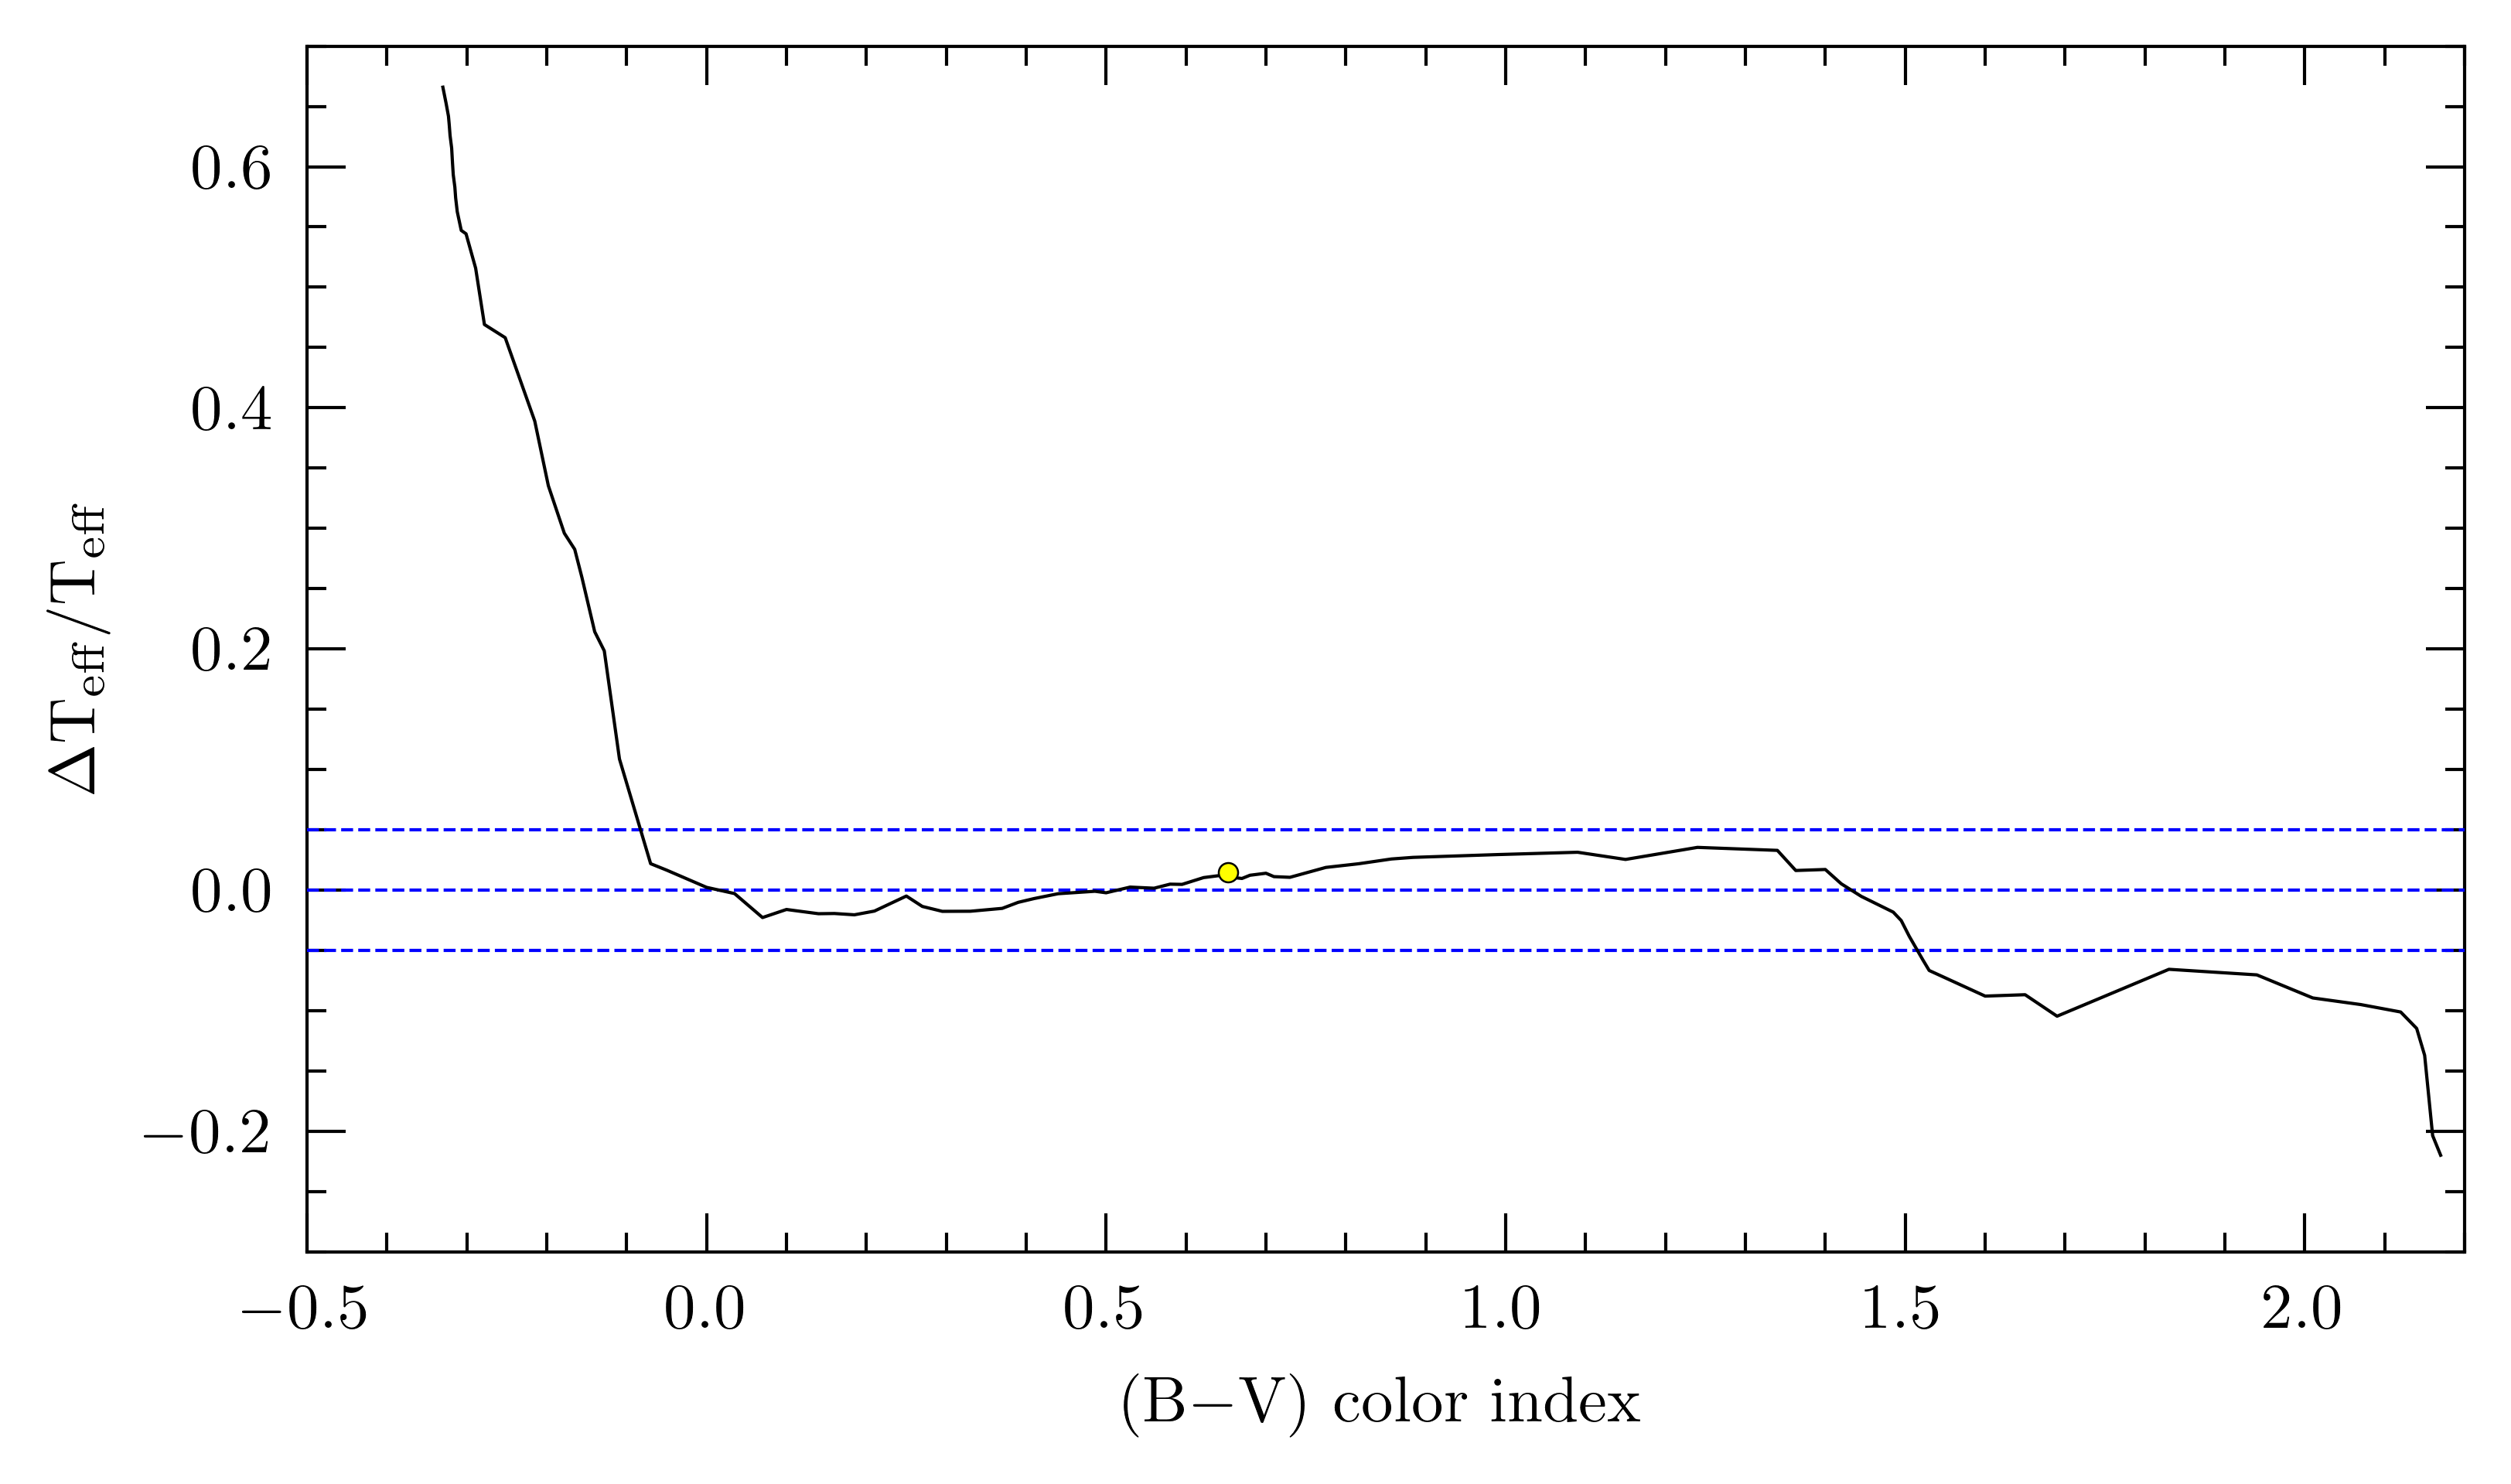

In [35]:
# empirical Teff for each tabulated B-V color

empTeff = 9000.0/(bvColor+0.93)

dTeff = (Teff - empTeff)/Teff # fractional deviation between actual Teff - empirical Teff

empSun = 9000.0/(bvSun+0.93)
dTsun = (teSun - empSun)/teSun

# make the plot

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)
    
ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

bvMin = -0.5
bvMax = 2.2

teMin = 2000 # K
teMax = 50000

ax.set_xlim(bvMin,bvMax)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_xlabel(r'(B$-$V) color index',fontsize=axisFontSize)

ax.set_ylim(-0.3,0.7)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_ylabel(r'$\Delta$T$_{\rm eff}$/T$_{\rm eff}$',fontsize=axisFontSize)
              
ax.plot(bvColor,dTeff,'-',color='black',lw=0.5,zorder=8)

# boss! boss! the Sun! the Sun!

ax.plot(bvSun,dTsun,'o',ms=3,mfc='yellow',mec='black',mew=0.3,zorder=9)

ax.hlines([0.0,-0.05,0.05],bvMin,bvMax,ls=['--'],colors=['blue'],lw=0.5,zorder=7)

plotFile = f'Dwarf_Teff_Color_Empirical.png' 
plt.savefig(plotFile,bbox_inches='tight',facecolor='white')
plt.show()